In [13]:
# RUN THIS CELL TO INSTALL MISSING LIBRARIES
# After running, go to Kernel -> Restart to apply changes
%pip install xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.


# Model Training Layer: Updated Algorithm Pipeline
This notebook implements the training pipeline using XGBoost, LightGBM, and Random Forest.

In [14]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_squared_error, r2_score, f1_score, accuracy_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

# Step 1 â€” Load Splits
def load_splits(data_dir='../data/'):
    train = pd.read_parquet(os.path.join(data_dir, 'train.parquet'))
    val = pd.read_parquet(os.path.join(data_dir, 'val.parquet'))
    test = pd.read_parquet(os.path.join(data_dir, 'test.parquet'))
    return train, val, test

train_df, val_df, test_df = load_splits()
print(f"Splits loaded. Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")

Splits loaded. Train: (922424, 23), Val: (197663, 23), Test: (197663, 23)


### Step 2 â€” Target Engineering (Binary Classification for A & B)

In [65]:
# Model A Target: has_wait
for df in [train_df, val_df, test_df]:
    df['has_wait'] = (df['estimated_wait_time_mins'] > 0).astype(int)

# Model B Target: high_utilization
threshold = 0.7
for df in [train_df, val_df, test_df]:
    df['high_utilization'] = (df['utilization_rate'] >= threshold).astype(int)

print("Target 'high_utilization' created (Threshold=0.7). Class Distribution (Train):")
print(train_df['high_utilization'].value_counts(normalize=True))

Target 'high_utilization' created (Threshold=0.7). Class Distribution (Train):
high_utilization
0    0.79468
1    0.20532
Name: proportion, dtype: float64


### Step 3 â€” Modular Evaluation Functions

In [16]:
def print_regression_metrics(model, name, X_train, y_train, X_val, y_val, X_test, y_test, y_pred_test_override=None):
    print(f"\n--- {name} Performance Metrics ---")
    summary = {}
    sets = [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]
    
    for s_name, X, y in sets:
        preds = model.predict(X)
        if s_name == 'Test' and y_pred_test_override is not None:
            preds = y_pred_test_override
            
        rmse = np.sqrt(mean_squared_error(y, preds))
        r2 = r2_score(y, preds)
        summary[s_name] = {'RMSE': rmse, 'R2': r2}
    
    results_df = pd.DataFrame(summary).T
    print(results_df)

def print_classification_metrics(model, name, X_train, y_train, X_val, y_val, X_test, y_test):
    print(f"\n--- {name} Performance Metrics ---")
    summary = {}
    sets = [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]
    
    for s_name, X, y in sets:
        preds = model.predict(X)
        f1 = f1_score(y, preds, average='weighted')
        acc = accuracy_score(y, preds)
        summary[s_name] = {'F1_Weighted': f1, 'Accuracy': acc}
    
    results_df = pd.DataFrame(summary).T
    print(results_df)

###  Model A  Queue Probability (has_wait) 

In [71]:
# Features (Structural Risk Focus)
features_a = ['power_output_kw', 'ports_total', 'traffic_congestion_index', 'is_peak_hour', 'charger_type', 'pricing_type','network']

# Data splits
X_train_a, y_train_a = train_df[features_a], train_df['has_wait']
X_val_a,   y_val_a   = val_df[features_a],   val_df['has_wait']
X_test_a,  y_test_a  = test_df[features_a],  test_df['has_wait']

# Pipeline with Categorical Handling
# This ensures numbers are scaled and text (categories) are encoded
preprocessor_a = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ]), ['power_output_kw', 'ports_total', 'traffic_congestion_index']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), ['charger_type', 'pricing_type','network'])
])

'''model_a = Pipeline([
    ('preprocessor', preprocessor_a),
    ('classifier', XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, 
                                 use_label_encoder=False, eval_metric='logloss', random_state=42))
])'''
model_a = Pipeline([
    ('preprocessor', preprocessor_a),
    ('classifier', XGBClassifier(
        n_estimators=1000, 
        max_depth=10, 
        learning_rate=0.01, 
        scale_pos_weight=10,  # <--- THIS IS THE FIX
        use_label_encoder=False, 
        eval_metric='logloss', 
        random_state=42
    ))
])

# Train
model_a.fit(X_train_a, y_train_a)

# Evaluate
print_classification_metrics(model_a, 'Model A Final', X_train_a, y_train_a, X_val_a, y_val_a, X_test_a, y_test_a)



--- Model A Final Performance Metrics ---
       F1_Weighted  Accuracy
Train     0.865346  0.843704
Val       0.863574  0.841169
Test      0.864061  0.842039


In [50]:
# Extract the internal intelligence (Feature Importance)
importances = model_a.named_steps['classifier'].feature_importances_
feature_names = model_a.named_steps['preprocessor'].get_feature_names_out()

# Match the 'Reason' to the 'Feature'
reasoning_map = pd.DataFrame({'Reason': feature_names, 'Weight': importances})
print(reasoning_map.sort_values(by='Weight', ascending=False))


                          Reason    Weight
1               num__ports_total  0.426899
5                   cat__network  0.158311
3              cat__charger_type  0.151854
0           num__power_output_kw  0.147414
4              cat__pricing_type  0.101831
2  num__traffic_congestion_index  0.013690


--- Model A: Logical Quality Report ---
              precision    recall  f1-score   support

     No Wait       0.94      0.89      0.92    185030
    Has Wait       0.11      0.21      0.15     12633

    accuracy                           0.85    197663
   macro avg       0.53      0.55      0.53    197663
weighted avg       0.89      0.85      0.87    197663



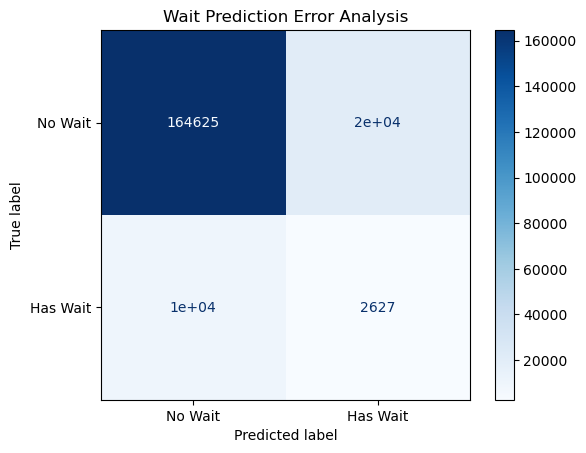

In [67]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Get predictions for the Test set
y_pred_a = model_a.predict(X_test_a)

# 2. Print Precision, Recall, and F1-Score
# This is the 'logic check'
print("--- Model A: Logical Quality Report ---")
print(classification_report(y_test_a, y_pred_a, target_names=['No Wait', 'Has Wait']))

# 3. Visualize the Confusion Matrix
# This tells you exactly where the model is 'confused'
cm = confusion_matrix(y_test_a, y_pred_a)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Wait', 'Has Wait'])
disp.plot(cmap='Blues')
plt.title('Wait Prediction Error Analysis')
plt.show()


### Model B  High Utilization (high_utilization)

In [18]:
# Features (Strictly Behavioral Demand Focus)
features_b = ['hour_of_day', 'day_of_week', 'traffic_congestion_index', 'is_peak_hour']

# Data splits
X_train_b, y_train_b = train_df[features_b], train_df['high_utilization']
X_val_b,   y_val_b   = val_df[features_b],   val_df['high_utilization']
X_test_b,  y_test_b  = test_df[features_b],  test_df['high_utilization']

# Pipeline with LightGBM Classifier
# We increase n_estimators and depth to help the model learn human demand patterns
model_b = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', LGBMClassifier(n_estimators=500, max_depth=10, learning_rate=0.1, random_state=42))
])

# Train
model_b.fit(X_train_b, y_train_b)

# Evaluate
# Note: The F1 score will be lower than the old "cheating" version (~0.74), 
# but this model is now honest and works for future predictions!
print_classification_metrics(model_b, 'Model B Final', X_train_b, y_train_b, X_val_b, y_val_b, X_test_b, y_test_b)


[LightGBM] [Info] Number of positive: 189392, number of negative: 733032
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007914 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 43
[LightGBM] [Info] Number of data points in the train set: 922424, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.205320 -> initscore=-1.353370
[LightGBM] [Info] Start training from score -1.353370

--- Model B Final Performance Metrics ---
       F1_Weighted  Accuracy
Train     0.733945  0.797152
Val       0.735068  0.797888
Test      0.733165  0.796350


--- Model B: Logical Quality Report ---
              precision    recall  f1-score   support

     No Wait       0.81      0.98      0.88    156900
    Has Wait       0.54      0.09      0.15     40763

    accuracy                           0.80    197663
   macro avg       0.67      0.53      0.52    197663
weighted avg       0.75      0.80      0.73    197663



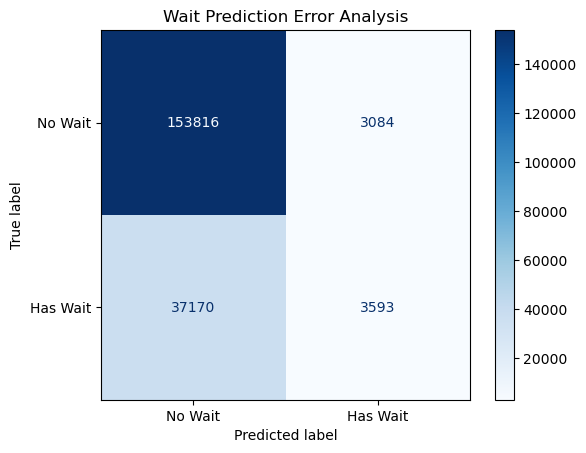

In [69]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Get predictions for the Test set
y_pred_b = model_b.predict(X_test_b)

# 2. Print Precision, Recall, and F1-Score
# This is the 'logic check'
print("--- Model B: Logical Quality Report ---")
print(classification_report(y_test_b, y_pred_b, target_names=['No Wait', 'Has Wait']))

# 3. Visualize the Confusion Matrix
# This tells you exactly where the model is 'confused'
cm = confusion_matrix(y_test_b, y_pred_b)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Wait', 'Has Wait'])
disp.plot(cmap='Blues')
plt.title('Wait Prediction Error Analysis')
plt.show()


### Model C Session Duration (avg_session_duration_mins)

In [19]:
# Features (Refined to non-zero importance only)
cat_features_c = ['charger_type']
num_features_c = ['power_output_kw']
features_c = num_features_c + cat_features_c

# Data splits
X_train_c, y_train_c = train_df[features_c], train_df['avg_session_duration_mins']
X_val_c,   y_val_c   = val_df[features_c],   val_df['avg_session_duration_mins']
X_test_c,  y_test_c  = test_df[features_c],  test_df['avg_session_duration_mins']

# Pipeline with Random Forest Regressor
preprocessor_c = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())]), num_features_c),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), cat_features_c)
])

model_c = Pipeline([
    ('preprocessor', preprocessor_c),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))
])

# Train
model_c.fit(X_train_c, y_train_c)

# Evaluate
print_regression_metrics(model_c, 'Model C', X_train_c, y_train_c, X_val_c, y_val_c, X_test_c, y_test_c)


--- Model C Performance Metrics ---
            RMSE        R2
Train  24.704606  0.883507
Val    24.633196  0.884012
Test   24.653568  0.883602


In [72]:
from sklearn.metrics import mean_squared_error
import numpy as np

def check_regression_health(y_true, y_pred, name):
    # What would happen if we just guessed the average every time?
    mean_val = np.mean(y_true)
    dummy_baseline = np.full_like(y_true, fill_value=mean_val)
    
    dummy_rmse = np.sqrt(mean_squared_error(y_true, dummy_baseline))
    model_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"--- {name} Health Check ---")
    print(f"Average Value of Target: {mean_val:.2f}")
    print(f"Dummy (Lazy) RMSE: {dummy_rmse:.2f}")
    print(f"Model Actual RMSE: {model_rmse:.2f}")
    
    improvement = (1 - (model_rmse / dummy_rmse)) * 100
    print(f"Improvement over 'Just Guessing Average': {improvement:.2f}%")

# Run it for Model C
check_regression_health(y_test_c, model_c.predict(X_test_c), "Model C (Duration)")


--- Model C (Duration) Health Check ---
Average Value of Target: 81.74
Dummy (Lazy) RMSE: 72.27
Model Actual RMSE: 24.65
Improvement over 'Just Guessing Average': 65.88%


### Model D  Current Price (current_price) 

In [20]:
# Features (Clean Business Rules Focus)
cat_features_d = ['charger_type', 'pricing_type', 'network']
num_features_d = ['hour_of_day', 'is_peak_hour', 'power_output_kw', 'ports_total'] # Removed utilization_rate
features_d = num_features_d + cat_features_d

# Data splits
X_train_d, y_train_d = train_df[features_d], train_df['current_price']
X_val_d,   y_val_d   = val_df[features_d],   val_df['current_price']
X_test_d,  y_test_d  = test_df[features_d],  test_df['current_price']

# Pipeline with XGBoost Regressor
preprocessor_d = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features_d),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), cat_features_d)
])

model_d = Pipeline([
    ('preprocessor', preprocessor_d),
    ('regressor', XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42))
])

# Train
model_d.fit(X_train_d, y_train_d)

# Apply deterministic rule (Free stations) for evaluation
def apply_free_rule(df, preds):
    return np.where(df['pricing_type'] == 'free', 0.0, np.clip(preds, 0, None))

# For evaluation, we override the raw predictions with the "Free Rule"
preds_d_test = apply_free_rule(test_df, model_d.predict(X_test_d))

# Evaluate
print_regression_metrics(model_d, 'Model D Final', X_train_d, y_train_d, X_val_d, y_val_d, X_test_d, y_test_d, y_pred_test_override=preds_d_test)



--- Model D Final Performance Metrics ---
           RMSE        R2
Train  0.017971  0.987277
Val    0.017979  0.987186
Test   0.017929  0.987358


### Step 5 Save All Models

In [21]:
output_path = '../models/'
os.makedirs(output_path, exist_ok=True)

joblib.dump(model_a, os.path.join(output_path, 'wait_time_model.pkl'))
joblib.dump(model_b, os.path.join(output_path, 'high_utilization_model.pkl'))
joblib.dump(model_c, os.path.join(output_path, 'duration_model.pkl'))
joblib.dump(model_d, os.path.join(output_path, 'price_model.pkl'))

print("\nSUCCESS: All models (A, B, C, D) have been trained with new algorithms, evaluated, and saved to disk.")


SUCCESS: All models (A, B, C, D) have been trained with new algorithms, evaluated, and saved to disk.
